In [2]:
# Loading data
import pandas as pd
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
import xgboost as xgb
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, classification_report
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
import xgboost as xgb
df = pd.read_csv('diabetes_prediction_dataset.csv')
df

,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
0,Female,80.0,0,1,never,25.19,6.6,140,0
1,Female,54.0,0,0,No Info,27.32,6.6,80,0
2,Male,28.0,0,0,never,27.32,5.7,158,0
3,Female,36.0,0,0,current,23.45,5.0,155,0
4,Male,76.0,1,1,current,20.14,4.8,155,0
...,...,...,...,...,...,...,...,...,...
99995,Female,80.0,0,0,No Info,27.32,6.2,90,0
99996,Female,2.0,0,0,No Info,17.37,6.5,100,0
99997,Male,66.0,0,0,former,27.83,5.7,155,0
99998,Female,24.0,0,0,never,35.42,4.0,100,0


In [3]:
# EXPLORATORY DATA ANALYSIS
# Basic dataset information

# Basic dataset information
print("\n Dataset Information:")
print(f"   Total patients: {len(df):,}")
print(f"   Total features: {len(df.columns)}")
print(f"   Memory usage: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")

# Data types
print("\n Column Data Types:")
print(df.dtypes)


 Dataset Information:
   Total patients: 100,000
   Total features: 9
   Memory usage: 17.31 MB

 Column Data Types:
gender                  object
age                    float64
hypertension             int64
heart_disease            int64
smoking_history         object
bmi                    float64
HbA1c_level            float64
blood_glucose_level      int64
diabetes                 int64
dtype: object


In [4]:
# Checking for missing values
print("\n Missing Values Analysis:")
missing_values = df.isnull().sum()
missing_percent = (missing_values / len(df)) * 100
missing_df = pd.DataFrame({'Missing Count': missing_values, 'Missing %': missing_percent})
missing_df = missing_df[missing_df['Missing Count'] > 0].sort_values('Missing %', ascending=False)
missing_df 


 Missing Values Analysis:


,Missing Count,Missing %


In [5]:
# Statistical summary of numerical columns
print("\n Statistical Summary of Numerical Features:")
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns
print(df[numeric_cols].describe().round(2))


 Statistical Summary of Numerical Features:
             age  hypertension  heart_disease        bmi  HbA1c_level  \
count  100000.00     100000.00      100000.00  100000.00    100000.00   
mean       41.89          0.07           0.04      27.32         5.53   
std        22.52          0.26           0.19       6.64         1.07   
min         0.08          0.00           0.00      10.01         3.50   
25%        24.00          0.00           0.00      23.63         4.80   
50%        43.00          0.00           0.00      27.32         5.80   
75%        60.00          0.00           0.00      29.58         6.20   
max        80.00          1.00           1.00      95.69         9.00   

       blood_glucose_level   diabetes  
count            100000.00  100000.00  
mean                138.06       0.08  
std                  40.71       0.28  
min                  80.00       0.00  
25%                 100.00       0.00  
50%                 140.00       0.00  
75%              

In [6]:
# Statistical summary of categorical features
print("\n Statistical Summary of Categorical Features:")
categorical_cols = df.select_dtypes(include=['object']).columns
for col in categorical_cols:
    print(f"\n   {col}:")
    print(f"   Unique values: {df[col].nunique()}")
    print(f"   Value counts:")
    for val, count in df[col].value_counts().head(5).items():
        print(f"      {val}: {count:,} ({count/len(df)*100:.1f}%)")


 Statistical Summary of Categorical Features:

   gender:
   Unique values: 3
   Value counts:
      Female: 58,552 (58.6%)
      Male: 41,430 (41.4%)
      Other: 18 (0.0%)

   smoking_history:
   Unique values: 6
   Value counts:
      No Info: 35,816 (35.8%)
      never: 35,095 (35.1%)
      former: 9,352 (9.4%)
      current: 9,286 (9.3%)
      not current: 6,447 (6.4%)


In [7]:
# Target variable analysis

print("TARGET VARIABLE ANALYSIS (Diabetes Status)")


print(f"\n   No Diabetes (0): {(df['diabetes'] == 0).sum():,} patients ({(df['diabetes'] == 0).mean()*100:.2f}%)")
print(f"   Diabetes (1): {(df['diabetes'] == 1).sum():,} patients ({(df['diabetes'] == 1).mean()*100:.2f}%)")

TARGET VARIABLE ANALYSIS (Diabetes Status)

   No Diabetes (0): 91,500 patients (91.50%)
   Diabetes (1): 8,500 patients (8.50%)


In [8]:
# Checking for class imbalance
diabetes_percentage = (df['diabetes'] == 1).mean() * 100
if diabetes_percentage < 20:
    print(f"\n Note: Class imbalance detected! Only {diabetes_percentage:.1f}% have diabetes.")
    print("   This will be addressed using class weighting during modeling.")


 Note: Class imbalance detected! Only 8.5% have diabetes.
   This will be addressed using class weighting during modeling.


In [9]:
# Setting the style for better looking plots
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 11


 Generating Plot 1: Diabetes Distribution...


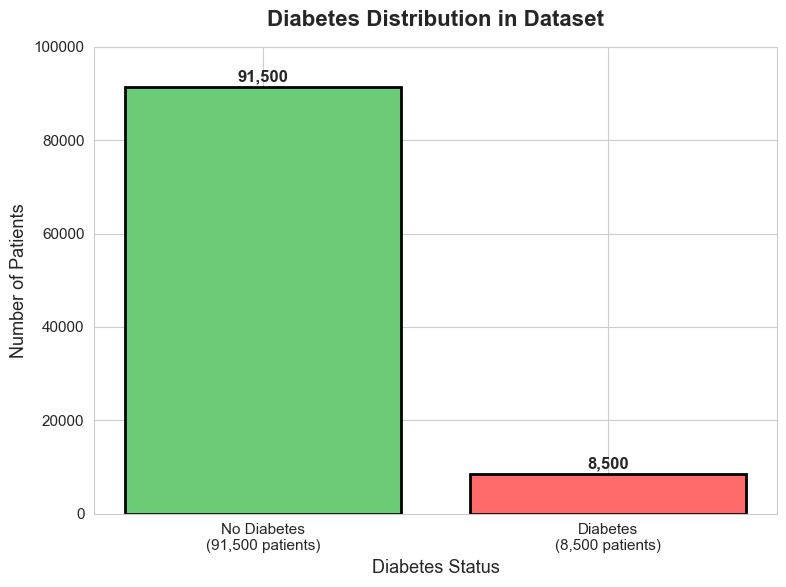

   ✓ Saved as 'plot_1_diabetes_distribution.png'


In [10]:

# PLOT 1: Target Distribution (Bar Chart)


print("\n Generating Plot 1: Diabetes Distribution...")

fig, ax = plt.subplots(figsize=(8, 6))
target_counts = df['diabetes'].value_counts()
colors_bar = ['#6bcb77', '#ff6b6b']
bars = ax.bar(['No Diabetes\n(91,500 patients)', 'Diabetes\n(8,500 patients)'], 
              target_counts.values, color=colors_bar, edgecolor='black', linewidth=2)
ax.set_title('Diabetes Distribution in Dataset', fontsize=16, fontweight='bold', pad=15)
ax.set_ylabel('Number of Patients', fontsize=13)
ax.set_xlabel('Diabetes Status', fontsize=13)

# Adding value labels on top of bars
for bar, count in zip(bars, target_counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 500, f'{count:,}', 
            ha='center', va='bottom', fontsize=12, fontweight='bold')
ax.set_ylim(0, 100000)
plt.tight_layout()
plt.savefig('plot_1_diabetes_distribution.png', dpi=300, bbox_inches='tight')
plt.show()
print("   ✓ Saved as 'plot_1_diabetes_distribution.png'")


 Generating Plot 2: Age Distribution...


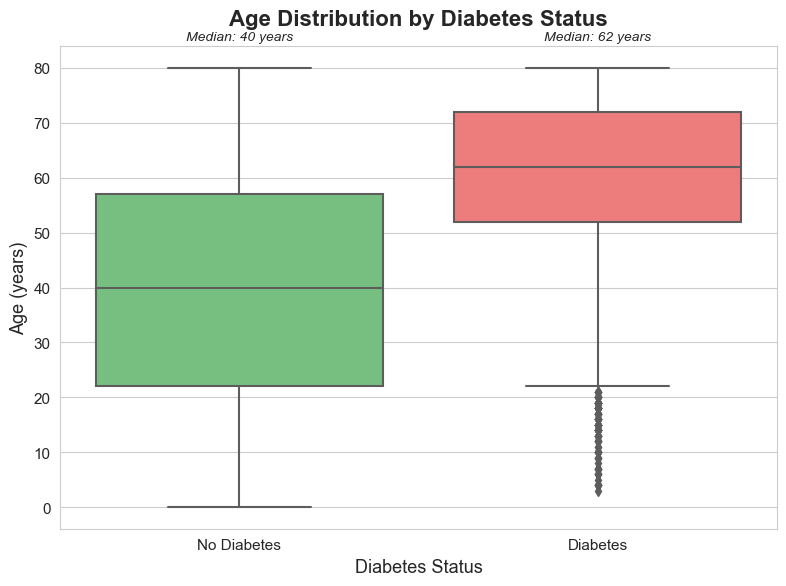

   ✓ Saved as 'plot_2_age_distribution.png'


In [11]:

# PLOT 2: Age Distribution by Diabetes Status


print("\n Generating Plot 2: Age Distribution...")

fig, ax = plt.subplots(figsize=(8, 6))
sns.boxplot(data=df, x='diabetes', y='age', palette=['#6bcb77', '#ff6b6b'], ax=ax)
ax.set_xticklabels(['No Diabetes', 'Diabetes'])
ax.set_title('Age Distribution by Diabetes Status', fontsize=16, fontweight='bold', pad=15)
ax.set_xlabel('Diabetes Status', fontsize=13)
ax.set_ylabel('Age (years)', fontsize=13)

# Addding statistical annotations
no_diabetes_age = df[df['diabetes'] == 0]['age'].median()
diabetes_age = df[df['diabetes'] == 1]['age'].median()
ax.text(0, 85, f'Median: {no_diabetes_age:.0f} years', ha='center', fontsize=10, style='italic')
ax.text(1, 85, f'Median: {diabetes_age:.0f} years', ha='center', fontsize=10, style='italic')

plt.tight_layout()
plt.savefig('plot_2_age_distribution.png', dpi=300, bbox_inches='tight')
plt.show()
print("   ✓ Saved as 'plot_2_age_distribution.png'")


 Generating Plot 3: BMI Distribution...


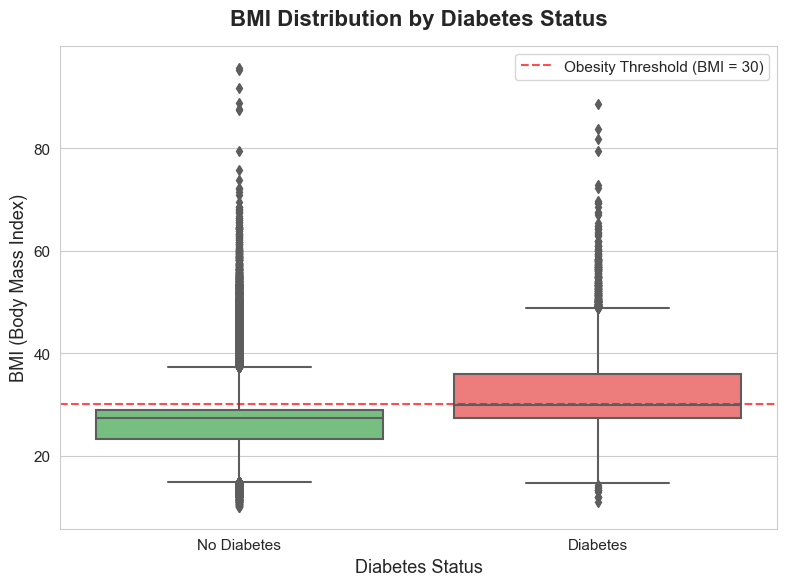

   ✓ Saved as 'plot_3_bmi_distribution.png'


In [12]:

# PLOT 3: BMI Distribution by Diabetes Status


print("\n Generating Plot 3: BMI Distribution...")

fig, ax = plt.subplots(figsize=(8, 6))
sns.boxplot(data=df, x='diabetes', y='bmi', palette=['#6bcb77', '#ff6b6b'], ax=ax)
ax.set_xticklabels(['No Diabetes', 'Diabetes'])
ax.set_title('BMI Distribution by Diabetes Status', fontsize=16, fontweight='bold', pad=15)
ax.set_xlabel('Diabetes Status', fontsize=13)
ax.set_ylabel('BMI (Body Mass Index)', fontsize=13)

# Addding BMI threshold line
ax.axhline(y=30, color='red', linestyle='--', alpha=0.7, label='Obesity Threshold (BMI = 30)')
ax.legend()

plt.tight_layout()
plt.savefig('plot_3_bmi_distribution.png', dpi=300, bbox_inches='tight')
plt.show()
print("   ✓ Saved as 'plot_3_bmi_distribution.png'")


 Generating Plot 4: Blood Glucose Distribution...


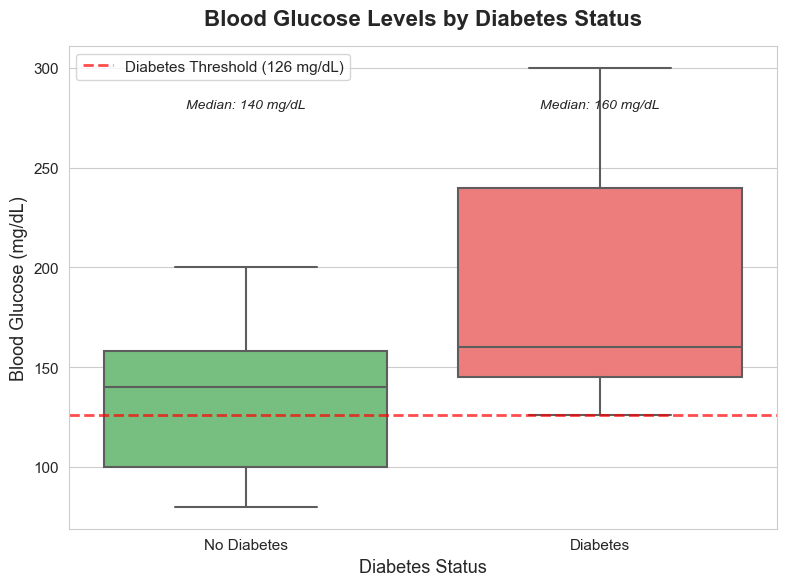

   ✓ Saved as 'plot_4_glucose_distribution.png'


In [13]:

# PLOT 4: Blood Glucose Levels by Diabetes Status


print("\n Generating Plot 4: Blood Glucose Distribution...")

fig, ax = plt.subplots(figsize=(8, 6))
sns.boxplot(data=df, x='diabetes', y='blood_glucose_level', palette=['#6bcb77', '#ff6b6b'], ax=ax)
ax.set_xticklabels(['No Diabetes', 'Diabetes'])
ax.set_title('Blood Glucose Levels by Diabetes Status', fontsize=16, fontweight='bold', pad=15)
ax.set_xlabel('Diabetes Status', fontsize=13)
ax.set_ylabel('Blood Glucose (mg/dL)', fontsize=13)
ax.axhline(y=126, color='red', linestyle='--', alpha=0.7, linewidth=2, label='Diabetes Threshold (126 mg/dL)')
ax.legend()

# Addding median annotations
no_diabetes_glucose = df[df['diabetes'] == 0]['blood_glucose_level'].median()
diabetes_glucose = df[df['diabetes'] == 1]['blood_glucose_level'].median()
ax.text(0, 280, f'Median: {no_diabetes_glucose:.0f} mg/dL', ha='center', fontsize=10, style='italic')
ax.text(1, 280, f'Median: {diabetes_glucose:.0f} mg/dL', ha='center', fontsize=10, style='italic')

plt.tight_layout()
plt.savefig('plot_4_glucose_distribution.png', dpi=300, bbox_inches='tight')
plt.show()
print("   ✓ Saved as 'plot_4_glucose_distribution.png'")


 Generating Plot 5: HbA1c Distribution...


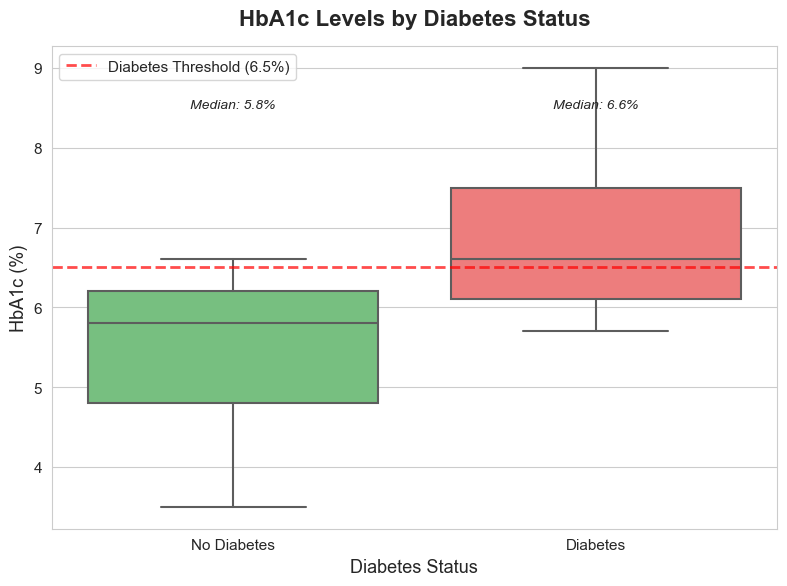

   ✓ Saved as 'plot_5_hba1c_distribution.png'


In [14]:

# PLOT 5: HbA1c Levels by Diabetes Status


print("\n Generating Plot 5: HbA1c Distribution...")

fig, ax = plt.subplots(figsize=(8, 6))
sns.boxplot(data=df, x='diabetes', y='HbA1c_level', palette=['#6bcb77', '#ff6b6b'], ax=ax)
ax.set_xticklabels(['No Diabetes', 'Diabetes'])
ax.set_title('HbA1c Levels by Diabetes Status', fontsize=16, fontweight='bold', pad=15)
ax.set_xlabel('Diabetes Status', fontsize=13)
ax.set_ylabel('HbA1c (%)', fontsize=13)
ax.axhline(y=6.5, color='red', linestyle='--', alpha=0.7, linewidth=2, label='Diabetes Threshold (6.5%)')
ax.legend()

# Adding median annotations
no_diabetes_hba1c = df[df['diabetes'] == 0]['HbA1c_level'].median()
diabetes_hba1c = df[df['diabetes'] == 1]['HbA1c_level'].median()
ax.text(0, 8.5, f'Median: {no_diabetes_hba1c:.1f}%', ha='center', fontsize=10, style='italic')
ax.text(1, 8.5, f'Median: {diabetes_hba1c:.1f}%', ha='center', fontsize=10, style='italic')

plt.tight_layout()
plt.savefig('plot_5_hba1c_distribution.png', dpi=300, bbox_inches='tight')
plt.show()
print("   ✓ Saved as 'plot_5_hba1c_distribution.png'")



 Generating Plot 6: Diabetes Rate by Gender...


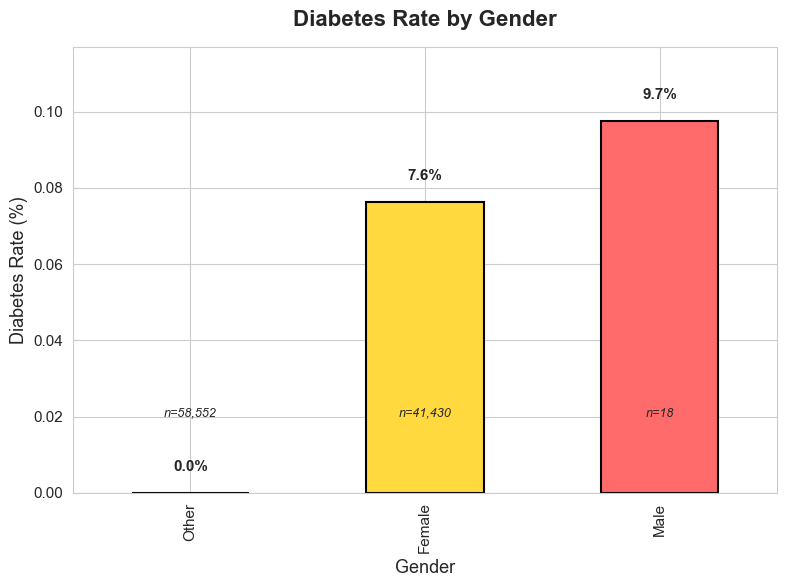

   ✓ Saved as 'plot_6_gender_analysis.png'


In [15]:

# PLOT 6: Diabetes Rate by Gender


print("\n Generating Plot 6: Diabetes Rate by Gender...")

fig, ax = plt.subplots(figsize=(8, 6))
gender_diabetes = df.groupby('gender')['diabetes'].mean().sort_values()
colors_gender = ['#6bcb77', '#ffd93d', '#ff6b6b']
bars = gender_diabetes.plot(kind='bar', color=colors_gender, ax=ax, edgecolor='black', linewidth=1.5)
ax.set_title('Diabetes Rate by Gender', fontsize=16, fontweight='bold', pad=15)
ax.set_xlabel('Gender', fontsize=13)
ax.set_ylabel('Diabetes Rate (%)', fontsize=13)
ax.set_ylim(0, max(gender_diabetes) * 1.2)

# Adding value labels
for i, (idx, v) in enumerate(gender_diabetes.items()):
    ax.text(i, v + 0.005, f'{v*100:.1f}%', ha='center', va='bottom', fontsize=11, fontweight='bold')

# Adding count annotations
gender_counts = df['gender'].value_counts()
for i, (idx, count) in enumerate(gender_counts.items()):
    ax.text(i, 0.02, f'n={count:,}', ha='center', fontsize=9, style='italic')

plt.tight_layout()
plt.savefig('plot_6_gender_analysis.png', dpi=300, bbox_inches='tight')
plt.show()
print("   ✓ Saved as 'plot_6_gender_analysis.png'")



 Generating Plot 7: Diabetes Rate by Hypertension...


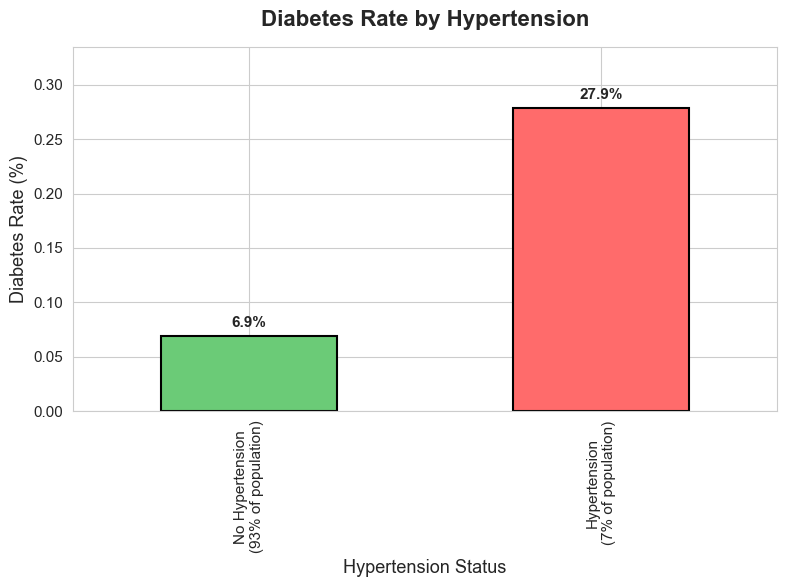

   ✓ Saved as 'plot_7_hypertension_analysis.png'


In [16]:

# PLOT 7: Diabetes Rate by Hypertension


print("\n Generating Plot 7: Diabetes Rate by Hypertension...")

fig, ax = plt.subplots(figsize=(8, 6))
hypertension_diabetes = df.groupby('hypertension')['diabetes'].mean()
colors_hypertension = ['#6bcb77', '#ff6b6b']
bars = hypertension_diabetes.plot(kind='bar', color=colors_hypertension, ax=ax, edgecolor='black', linewidth=1.5)
ax.set_title('Diabetes Rate by Hypertension', fontsize=16, fontweight='bold', pad=15)
ax.set_xlabel('Hypertension Status', fontsize=13)
ax.set_ylabel('Diabetes Rate (%)', fontsize=13)
ax.set_xticklabels(['No Hypertension\n(93% of population)', 'Hypertension\n(7% of population)'])
ax.set_ylim(0, max(hypertension_diabetes) * 1.2)

for i, (idx, v) in enumerate(hypertension_diabetes.items()):
    ax.text(i, v + 0.005, f'{v*100:.1f}%', ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.savefig('plot_7_hypertension_analysis.png', dpi=300, bbox_inches='tight')
plt.show()
print("   ✓ Saved as 'plot_7_hypertension_analysis.png'")


 Generating Plot 8: Diabetes Rate by Heart Disease...


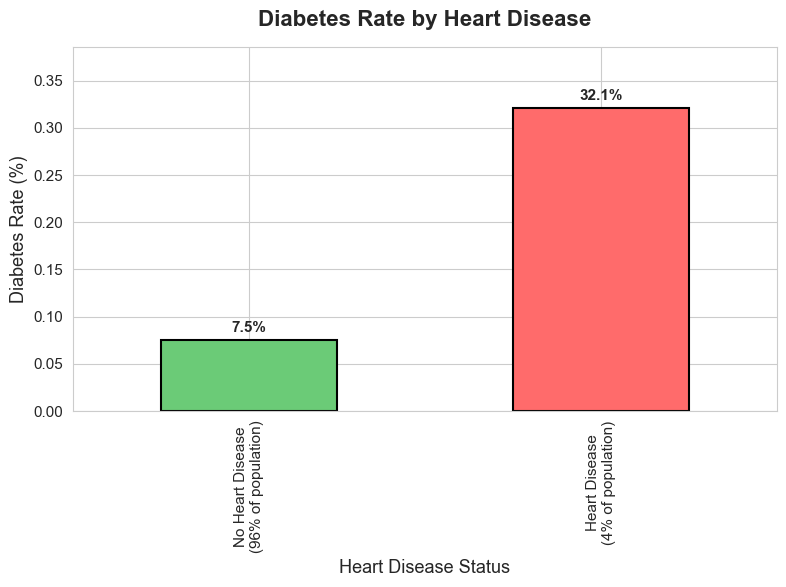

   ✓ Saved as 'plot_8_heart_disease_analysis.png'


In [17]:

# PLOT 8: Diabetes Rate by Heart Disease

print("\n Generating Plot 8: Diabetes Rate by Heart Disease...")

fig, ax = plt.subplots(figsize=(8, 6))
heart_diabetes = df.groupby('heart_disease')['diabetes'].mean()
colors_heart = ['#6bcb77', '#ff6b6b']
bars = heart_diabetes.plot(kind='bar', color=colors_heart, ax=ax, edgecolor='black', linewidth=1.5)
ax.set_title('Diabetes Rate by Heart Disease', fontsize=16, fontweight='bold', pad=15)
ax.set_xlabel('Heart Disease Status', fontsize=13)
ax.set_ylabel('Diabetes Rate (%)', fontsize=13)
ax.set_xticklabels(['No Heart Disease\n(96% of population)', 'Heart Disease\n(4% of population)'])
ax.set_ylim(0, max(heart_diabetes) * 1.2)

for i, (idx, v) in enumerate(heart_diabetes.items()):
    ax.text(i, v + 0.005, f'{v*100:.1f}%', ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.savefig('plot_8_heart_disease_analysis.png', dpi=300, bbox_inches='tight')
plt.show()
print("   ✓ Saved as 'plot_8_heart_disease_analysis.png'")



 Generating Plot 9: Correlation Heatmap...


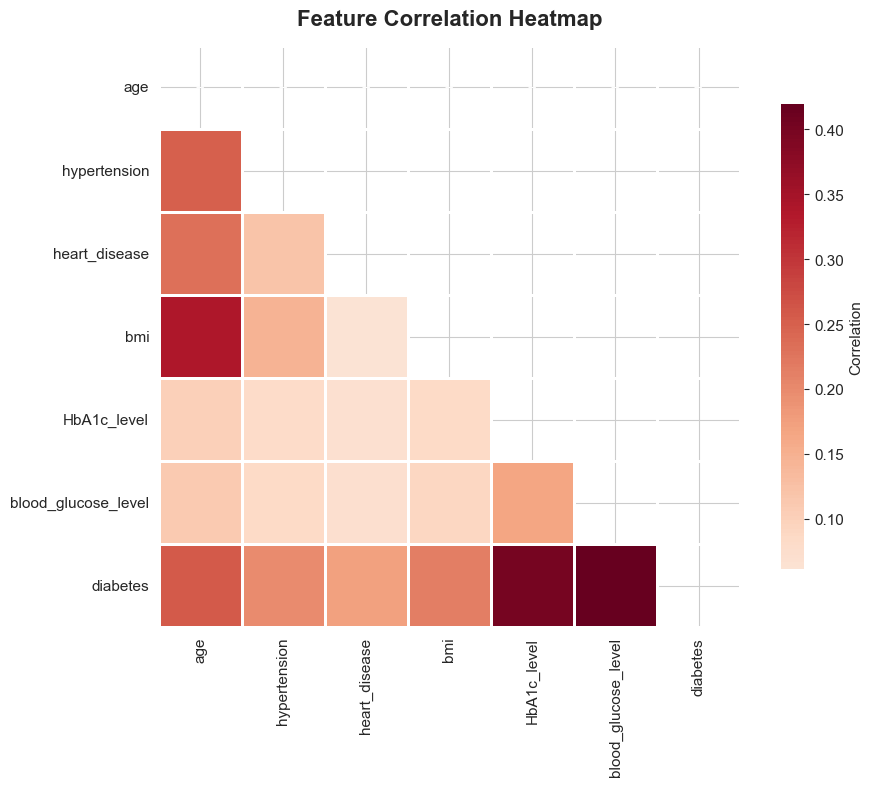

   ✓ Saved as 'plot_9_correlation_heatmap.png'


In [18]:

# PLOT 9: Correlation Heatmap

print("\n Generating Plot 9: Correlation Heatmap...")

fig, ax = plt.subplots(figsize=(10, 8))
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns
numeric_df = df[numeric_cols]
correlation_matrix = numeric_df.corr()
mask = np.triu(np.ones_like(correlation_matrix, dtype=bool))
sns.heatmap(correlation_matrix, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r', 
            center=0, square=True, linewidths=1, cbar_kws={"shrink": 0.8, "label": "Correlation"}, 
            annot_kws={'size': 10}, ax=ax)
ax.set_title('Feature Correlation Heatmap', fontsize=16, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig('plot_9_correlation_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()
print("   ✓ Saved as 'plot_9_correlation_heatmap.png'")


In [19]:
# Making a copy of the original dataframe
df_processed = df.copy()

# Displaying the current columns
print("\n Original Columns:")
print(df_processed.columns.tolist())

# Encoding categorical variables
print("\n Encoding Categorical Variables...")

# Encoding gender
gender_mapping = {'Female': 0, 'Male': 1, 'Other': 2}
df_processed['gender'] = df_processed['gender'].map(gender_mapping)
print("    Gender encoded (Female=0, Male=1, Other=2)")

# Encoding smoking history
smoking_mapping = {
    'never': 0,
    'former': 1,
    'current': 2,
    'ever': 3,
    'not current': 4,
    'No Info': 5
}
df_processed['smoking_history'] = df_processed['smoking_history'].map(smoking_mapping)
print("   ✓ Smoking history encoded")

# Verify encoding
print("\n Encoded Value Distribution:")
print("\nGender distribution after encoding:")
print(df_processed['gender'].value_counts())
print("\nSmoking history distribution after encoding:")
print(df_processed['smoking_history'].value_counts())




 Original Columns:
['gender', 'age', 'hypertension', 'heart_disease', 'smoking_history', 'bmi', 'HbA1c_level', 'blood_glucose_level', 'diabetes']

 Encoding Categorical Variables...
    Gender encoded (Female=0, Male=1, Other=2)
   ✓ Smoking history encoded

 Encoded Value Distribution:

Gender distribution after encoding:
gender
0    58552
1    41430
2       18
Name: count, dtype: int64

Smoking history distribution after encoding:
smoking_history
5    35816
0    35095
1     9352
2     9286
4     6447
3     4004
Name: count, dtype: int64


In [20]:
# Feature Engineering - Creating new meaningful features
print("\n Creating Engineered Features...")

# 1. BMI categories (clinical classification)
def bmi_category(bmi):
    if bmi < 18.5:
        return 0  # Underweight
    elif bmi < 25:
        return 1  # Normal weight
    elif bmi < 30:
        return 2  # Overweight
    else:
        return 3  # Obese

df_processed['bmi_category'] = df_processed['bmi'].apply(bmi_category)
print("   ✓ BMI categories created")
print("     - 0: Underweight (BMI < 18.5)")
print("     - 1: Normal weight (BMI 18.5-25)")
print("     - 2: Overweight (BMI 25-30)")
print("     - 3: Obese (BMI > 30)")

# 2. Age groups
def age_group(age):
    if age < 30:
        return 0  # Young adult
    elif age < 45:
        return 1  # Adult
    elif age < 60:
        return 2  # Middle age
    else:
        return 3  # Senior

df_processed['age_group'] = df_processed['age'].apply(age_group)
print("   ✓ Age groups created")
print("     - 0: Young adult (<30 years)")
print("     - 1: Adult (30-45 years)")
print("     - 2: Middle age (45-60 years)")
print("     - 3: Senior (>60 years)")

# 3. Glucose-HbA1c interaction (combined risk indicator)
df_processed['glucose_hba1c_ratio'] = df_processed['blood_glucose_level'] / (df_processed['HbA1c_level'] + 0.1)
print("   ✓ Glucose-HbA1c ratio created")
print("     - Higher ratio indicates higher diabetes risk")

# 4. Age-BMI interaction (metabolic risk)
df_processed['age_bmi_interaction'] = (df_processed['age'] * df_processed['bmi']) / 100
print("   ✓ Age-BMI interaction created")
print("     - Higher value indicates cumulative metabolic risk")




 Creating Engineered Features...
   ✓ BMI categories created
     - 0: Underweight (BMI < 18.5)
     - 1: Normal weight (BMI 18.5-25)
     - 2: Overweight (BMI 25-30)
     - 3: Obese (BMI > 30)
   ✓ Age groups created
     - 0: Young adult (<30 years)
     - 1: Adult (30-45 years)
     - 2: Middle age (45-60 years)
     - 3: Senior (>60 years)
   ✓ Glucose-HbA1c ratio created
     - Higher ratio indicates higher diabetes risk
   ✓ Age-BMI interaction created
     - Higher value indicates cumulative metabolic risk


In [21]:
# 5. Combined risk score (simple heuristic for initial screening)
df_processed['risk_score'] = (
    (df_processed['HbA1c_level'] >= 6.5).astype(int) * 3 +      # Diabetic range
    (df_processed['blood_glucose_level'] >= 140).astype(int) * 2 + # High glucose
    (df_processed['bmi'] >= 30).astype(int) * 1 +                # Obese
    (df_processed['hypertension'] == 1).astype(int) * 1 +        # Hypertension
    (df_processed['heart_disease'] == 1).astype(int) * 1         # Heart disease
)
print("   ✓ Combined risk score created (range 0-8)")
print("     - 0-2: Low risk")
print("     - 3-5: Moderate risk")
print("     - 6-8: High risk")

# Displaying risk score distribution
print("\n Risk Score Distribution:")
risk_dist = df_processed['risk_score'].value_counts().sort_index()
for score, count in risk_dist.items():
    percentage = count / len(df_processed) * 100
    print(f"   Risk Score {score}: {count:,} patients ({percentage:.1f}%)")

# Displaying updated feature list
print(f"\n Final Feature Set ({len(df_processed.columns) - 1} features):")
for col in df_processed.columns:
    if col != 'diabetes':
        print(f"   - {col}")

   ✓ Combined risk score created (range 0-8)
     - 0-2: Low risk
     - 3-5: Moderate risk
     - 6-8: High risk

 Risk Score Distribution:
   Risk Score 0: 25,881 patients (25.9%)
   Risk Score 1: 8,407 patients (8.4%)
   Risk Score 2: 32,157 patients (32.2%)
   Risk Score 3: 16,531 patients (16.5%)
   Risk Score 4: 3,785 patients (3.8%)
   Risk Score 5: 8,148 patients (8.1%)
   Risk Score 6: 3,869 patients (3.9%)
   Risk Score 7: 1,110 patients (1.1%)
   Risk Score 8: 112 patients (0.1%)

 Final Feature Set (13 features):
   - gender
   - age
   - hypertension
   - heart_disease
   - smoking_history
   - bmi
   - HbA1c_level
   - blood_glucose_level
   - bmi_category
   - age_group
   - glucose_hba1c_ratio
   - age_bmi_interaction
   - risk_score


In [22]:

# PART 4: TRAIN-TEST SPLIT AND FEATURE SCALING

print("TRAIN-TEST SPLIT AND FEATURE SCALING")


# Separating features and target
X = df_processed.drop('diabetes', axis=1)
y = df_processed['diabetes']

print(f"\n Feature Matrix (X): {X.shape}")
print(f"   Target Vector (y): {y.shape}")

TRAIN-TEST SPLIT AND FEATURE SCALING

 Feature Matrix (X): (100000, 13)
   Target Vector (y): (100000,)


In [23]:
# Train-test split (stratified to maintain class distribution)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"\n Train-Test Split Complete:")
print(f"   Training set: {X_train.shape[0]:,} samples ({X_train.shape[0]/len(df)*100:.1f}%)")
print(f"   Test set: {X_test.shape[0]:,} samples ({X_test.shape[0]/len(df)*100:.1f}%)")


 Train-Test Split Complete:
   Training set: 80,000 samples (80.0%)
   Test set: 20,000 samples (20.0%)


In [24]:
# Checking class distribution in splits
print(f"\n Class Distribution in Training Set:")
print(f"   No Diabetes: {(y_train == 0).sum():,} ({(y_train == 0).mean()*100:.2f}%)")
print(f"   Diabetes: {(y_train == 1).sum():,} ({(y_train == 1).mean()*100:.2f}%)")

print(f"\n Class Distribution in Test Set:")
print(f"   No Diabetes: {(y_test == 0).sum():,} ({(y_test == 0).mean()*100:.2f}%)")
print(f"   Diabetes: {(y_test == 1).sum():,} ({(y_test == 1).mean()*100:.2f}%)")


 Class Distribution in Training Set:
   No Diabetes: 73,200 (91.50%)
   Diabetes: 6,800 (8.50%)

 Class Distribution in Test Set:
   No Diabetes: 18,300 (91.50%)
   Diabetes: 1,700 (8.50%)


In [25]:
# Identifying numerical features for scaling
numerical_features = ['age', 'bmi', 'HbA1c_level', 'blood_glucose_level', 
                      'glucose_hba1c_ratio', 'age_bmi_interaction', 'risk_score']

print(f"\n Numerical Features to be Scaled:")
for feat in numerical_features:
    print(f"   - {feat}")


 Numerical Features to be Scaled:
   - age
   - bmi
   - HbA1c_level
   - blood_glucose_level
   - glucose_hba1c_ratio
   - age_bmi_interaction
   - risk_score


In [26]:
# Applying StandardScaler
scaler = StandardScaler()

X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

X_train_scaled[numerical_features] = scaler.fit_transform(X_train[numerical_features])
X_test_scaled[numerical_features] = scaler.transform(X_test[numerical_features])

print("\n Feature scaling completed!")
print("   - Features transformed to have mean = 0 and standard deviation = 1")
print("   - Scaler saved for future predictions")

# Displaying scaling statistics
print("\n Scaling Statistics:")
for feat in numerical_features:
    mean = X_train[feat].mean()
    std = X_train[feat].std()
    print(f"   {feat}: mean = {mean:.2f}, std = {std:.2f}")

# Saving the scaler for deployment
import joblib
import os

os.makedirs('models', exist_ok=True)
joblib.dump(scaler, 'models/scaler.pkl')
print("\n Scaler saved to 'models/scaler.pkl'")

# Saving feature columns for deployment
feature_columns = X.columns.tolist()
joblib.dump(feature_columns, 'models/feature_columns.pkl')
print(" Feature columns saved to 'models/feature_columns.pkl'")


 Feature scaling completed!
   - Features transformed to have mean = 0 and standard deviation = 1
   - Scaler saved for future predictions

 Scaling Statistics:
   age: mean = 41.90, std = 22.53
   bmi: mean = 27.32, std = 6.64
   HbA1c_level: mean = 5.53, std = 1.07
   blood_glucose_level: mean = 138.08, std = 40.66
   glucose_hba1c_ratio: mean = 25.34, std = 8.51
   age_bmi_interaction: mean = 11.95, std = 7.12
   risk_score: mean = 2.10, std = 1.76

 Scaler saved to 'models/scaler.pkl'
 Feature columns saved to 'models/feature_columns.pkl'



 Class Distribution Summary:
   Class 0 (No Diabetes): 73,200 patients (91.50%)
   Class 1 (Diabetes): 6,800 patients (8.50%)

 XGBoost scale_pos_weight: 10.76
   → Model will give 10.76x importance to diabetes class

 Sklearn Models: Will use class_weight='balanced' parameter
   → Automatically assigns higher weight to minority class


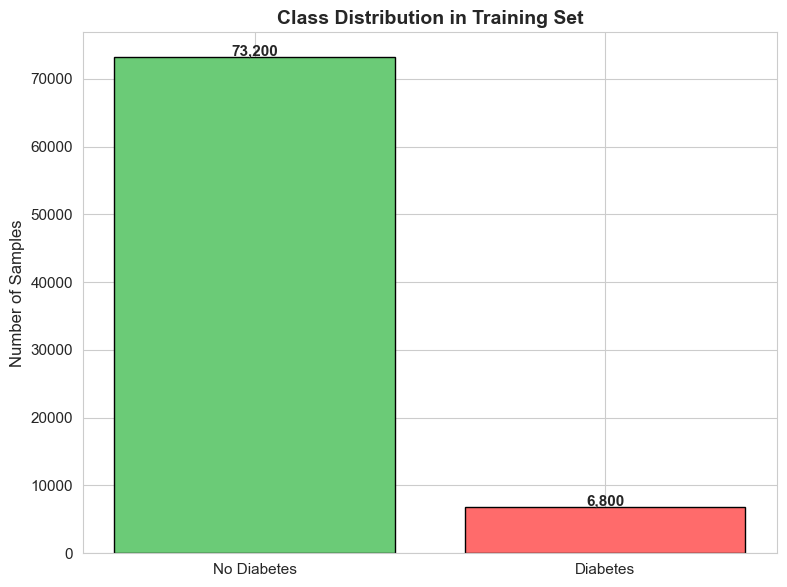


 Class imbalance analysis complete!
   → sklearn models: class_weight='balanced'
   → XGBoost: scale_pos_weight parameter


In [27]:

# PART 5: HANDLING CLASS IMBALANCE (SIMPLIFIED)

# Calculating class distribution
print(f"\n Class Distribution Summary:")
print(f"   Class 0 (No Diabetes): {(y_train == 0).sum():,} patients ({(y_train == 0).mean()*100:.2f}%)")
print(f"   Class 1 (Diabetes): {(y_train == 1).sum():,} patients ({(y_train == 1).mean()*100:.2f}%)")

# For XGBoost - calculate scale_pos_weight
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
print(f"\n XGBoost scale_pos_weight: {scale_pos_weight:.2f}")
print(f"   → Model will give {scale_pos_weight:.2f}x importance to diabetes class")

# For sklearn models - we'll use class_weight='balanced' directly in the model
print(f"\n Sklearn Models: Will use class_weight='balanced' parameter")
print(f"   → Automatically assigns higher weight to minority class")

# Visualizing class imbalance
fig, ax = plt.subplots(figsize=(8, 6))
ax.bar(['No Diabetes', 'Diabetes'], [(y_train == 0).sum(), (y_train == 1).sum()], 
       color=['#6bcb77', '#ff6b6b'], edgecolor='black')
ax.set_title('Class Distribution in Training Set', fontsize=14, fontweight='bold')
ax.set_ylabel('Number of Samples', fontsize=12)
for i, v in enumerate([(y_train == 0).sum(), (y_train == 1).sum()]):
    ax.text(i, v + 200, f'{v:,}', ha='center', fontsize=11, fontweight='bold')
plt.tight_layout()
plt.savefig('class_imbalance.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n Class imbalance analysis complete!")
print("   → sklearn models: class_weight='balanced'")
print("   → XGBoost: scale_pos_weight parameter")

In [28]:
# Defining models with class_weight to handle imbalance
models = {
    'Logistic Regression': LogisticRegression(
        max_iter=1000, 
        random_state=42,
        class_weight='balanced',
        solver='liblinear'
    ),
    'Decision Tree': DecisionTreeClassifier(
        max_depth=10,
        min_samples_split=5,
        min_samples_leaf=2,
        class_weight='balanced',
        random_state=42
    ),
    'Random Forest': RandomForestClassifier(
        n_estimators=200,
        max_depth=15,
        min_samples_split=5,
        min_samples_leaf=2,
        class_weight='balanced',
        random_state=42,
        n_jobs=-1
    ),
    'K-Nearest Neighbors': KNeighborsClassifier(
        n_neighbors=5,
        weights='distance'
    ),
    'XGBoost': xgb.XGBClassifier(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=6,
        subsample=0.8,
        colsample_bytree=0.8,
        scale_pos_weight=scale_pos_weight,
        random_state=42,
        eval_metric='logloss',
        use_label_encoder=False
    )
}


In [29]:
# Training and evaluate each model
results = []

print("\n Training and Evaluating Models...\n")
print("-" * 105)
print(f"{'Model':<22} {'Accuracy':<12} {'Precision':<12} {'Recall':<12} {'F1-Score':<12} {'AUC-ROC':<12}")
print("-" * 105)

for name, model in models.items():
    # Train the model
    model.fit(X_train_scaled, y_train)
    
    # Make predictions
    y_pred = model.predict(X_test_scaled)
    y_pred_proba = model.predict_proba(X_test_scaled)[:, 1]
    
    # Calculate metrics
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_pred_proba)
    
    results.append({
        'Model': name,
        'Accuracy': acc,
        'Precision': prec,
        'Recall': rec,
        'F1-Score': f1,
        'AUC-ROC': auc
    })
    
    print(f"{name:<22} {acc:<12.4f} {prec:<12.4f} {rec:<12.4f} {f1:<12.4f} {auc:<12.4f}")

print("-" * 105)

# Converting to DataFrame for better visualization
results_df = pd.DataFrame(results)
results_df


 Training and Evaluating Models...

---------------------------------------------------------------------------------------------------------
Model                  Accuracy     Precision    Recall       F1-Score     AUC-ROC     
---------------------------------------------------------------------------------------------------------
Logistic Regression    0.8911       0.4321       0.8965       0.5831       0.9654      
Decision Tree          0.8980       0.4506       0.9118       0.6031       0.9730      
Random Forest          0.9380       0.5948       0.8488       0.6995       0.9763      
K-Nearest Neighbors    0.9569       0.8327       0.6176       0.7092       0.8986      
XGBoost                0.9163       0.5044       0.9041       0.6476       0.9790      
---------------------------------------------------------------------------------------------------------


,Model,Accuracy,Precision,Recall,F1-Score,AUC-ROC
0,Logistic Regression,0.89105,0.432095,0.896471,0.583126,0.965442
1,Decision Tree,0.89800,0.450581,0.911765,0.603113,0.972954
2,Random Forest,0.93800,0.594806,0.848824,0.699467,0.976336
3,K-Nearest Neighbors,0.95695,0.832672,0.617647,0.709220,0.898643
4,XGBoost,0.91635,0.504431,0.904118,0.647567,0.978986


In [30]:

# BEST MODEL SELECTION

# For medical diagnosis, RECALL is most important (catch all diabetes cases)
best_recall_model = results_df.loc[results_df['Recall'].idxmax(), 'Model']
best_recall = results_df['Recall'].max()

# For balanced performance, F1-Score is best
best_f1_model = results_df.loc[results_df['F1-Score'].idxmax(), 'Model']
best_f1 = results_df['F1-Score'].max()

# For overall discrimination, AUC-ROC is best
best_auc_model = results_df.loc[results_df['AUC-ROC'].idxmax(), 'Model']
best_auc = results_df['AUC-ROC'].max()

print(f"\n Best Model by Recall (Catch Diabetes):")
print(f"   {best_recall_model} with Recall = {best_recall*100:.2f}%")

print(f"\n Best Model by F1-Score (Balance):")
print(f"   {best_f1_model} with F1-Score = {best_f1*100:.2f}%")

print(f"\n Best Model by AUC-ROC (Discrimination):")
print(f"   {best_auc_model} with AUC-ROC = {best_auc*100:.2f}%")

print(f"\n RECOMMENDED MODEL FOR DEPLOYMENT: {best_recall_model}")
print(f"   Reason: Highest recall ({best_recall*100:.2f}%) - catches most diabetes cases")
print(f"   This means fewer missed diagnoses (false negatives)")

# Store the best model for deployment
if best_recall_model == 'Random Forest':
    best_model = models['Random Forest']
elif best_recall_model == 'XGBoost':
    best_model = models['XGBoost']
elif best_recall_model == 'Decision Tree':
    best_model = models['Decision Tree']
else:
    best_model = models[best_recall_model]

print(f"\n Best model selected: {best_recall_model}")


 Best Model by Recall (Catch Diabetes):
   Decision Tree with Recall = 91.18%

 Best Model by F1-Score (Balance):
   K-Nearest Neighbors with F1-Score = 70.92%

 Best Model by AUC-ROC (Discrimination):
   XGBoost with AUC-ROC = 97.90%

 RECOMMENDED MODEL FOR DEPLOYMENT: Decision Tree
   Reason: Highest recall (91.18%) - catches most diabetes cases
   This means fewer missed diagnoses (false negatives)

 Best model selected: Decision Tree


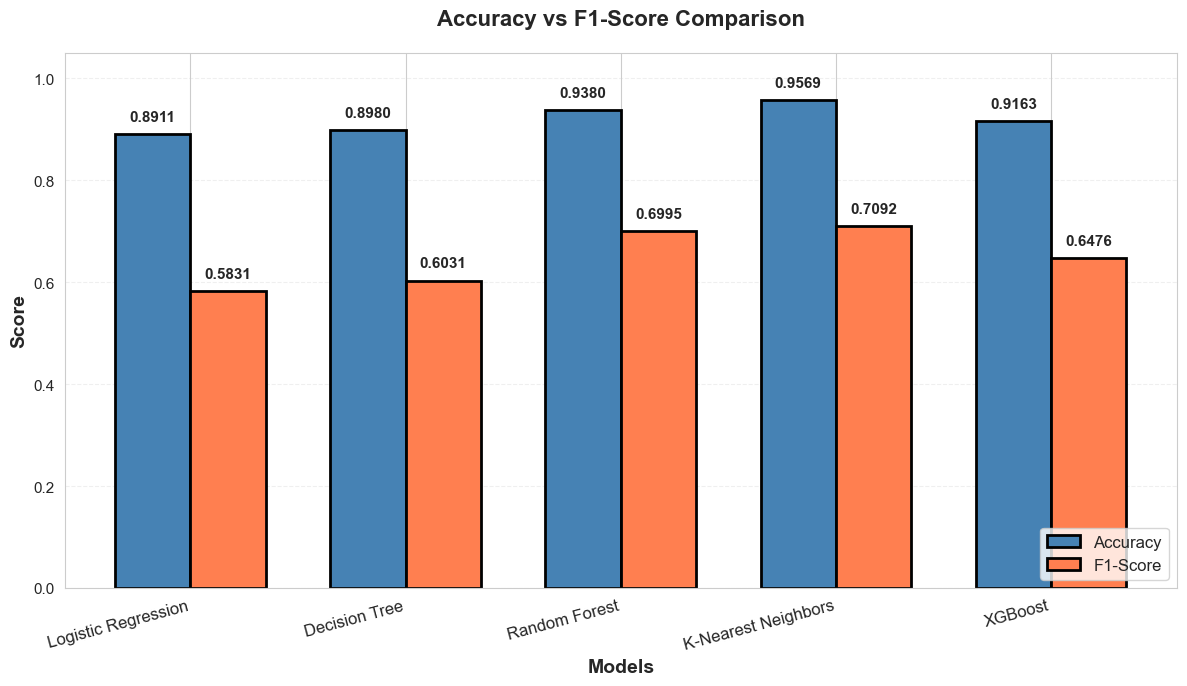


 Plot 1 saved as 'plot_1_accuracy_f1_comparison.png'


In [31]:

# PLOT 1: ACCURACY VS F1-SCORE COMPARISON

fig, ax = plt.subplots(figsize=(12, 7))

x = np.arange(len(results_df['Model']))
width = 0.35

# Create bars
bars1 = ax.bar(x - width/2, results_df['Accuracy'], width, label='Accuracy', 
               color='steelblue', edgecolor='black', linewidth=2)
bars2 = ax.bar(x + width/2, results_df['F1-Score'], width, label='F1-Score', 
               color='coral', edgecolor='black', linewidth=2)

# Customize plot
ax.set_xlabel('Models', fontsize=14, fontweight='bold')
ax.set_ylabel('Score', fontsize=14, fontweight='bold')
ax.set_title('Accuracy vs F1-Score Comparison', fontsize=16, fontweight='bold', pad=20)
ax.set_xticks(x)
ax.set_xticklabels(results_df['Model'], rotation=15, ha='right', fontsize=12)
ax.legend(fontsize=12, loc='lower right')
ax.set_ylim(0, 1.05)
ax.grid(axis='y', alpha=0.3, linestyle='--')

# Adding value labels on bars
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height + 0.02,
                f'{height:.4f}',
                ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.savefig('plot_1_accuracy_f1_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n Plot 1 saved as 'plot_1_accuracy_f1_comparison.png'")

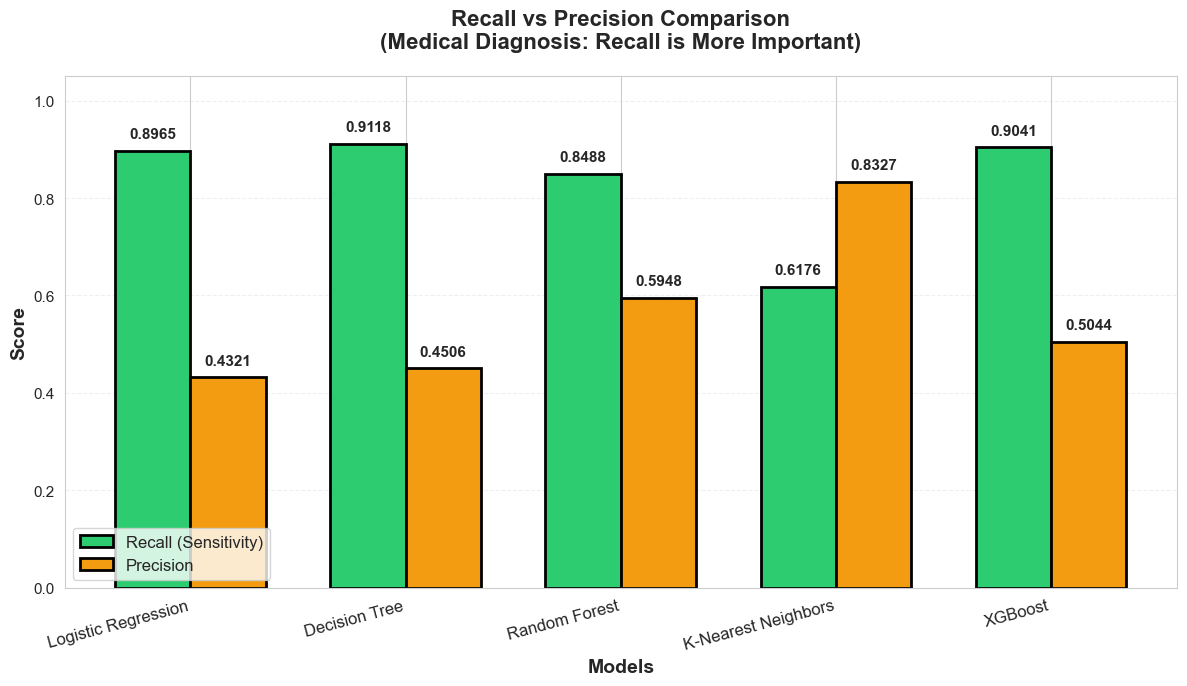


 Plot 2 saved as 'plot_2_recall_precision_comparison.png'


In [32]:

# PLOT 2: RECALL VS PRECISION COMPARISON


fig, ax = plt.subplots(figsize=(12, 7))

x = np.arange(len(results_df['Model']))
width = 0.35

# Creating bars
bars1 = ax.bar(x - width/2, results_df['Recall'], width, label='Recall (Sensitivity)', 
               color='#2ecc71', edgecolor='black', linewidth=2)
bars2 = ax.bar(x + width/2, results_df['Precision'], width, label='Precision', 
               color='#f39c12', edgecolor='black', linewidth=2)

# Customizing plot
ax.set_xlabel('Models', fontsize=14, fontweight='bold')
ax.set_ylabel('Score', fontsize=14, fontweight='bold')
ax.set_title('Recall vs Precision Comparison\n(Medical Diagnosis: Recall is More Important)', 
             fontsize=16, fontweight='bold', pad=20)
ax.set_xticks(x)
ax.set_xticklabels(results_df['Model'], rotation=15, ha='right', fontsize=12)
ax.legend(fontsize=12, loc='lower left')
ax.set_ylim(0, 1.05)
ax.grid(axis='y', alpha=0.3, linestyle='--')

# Adding value labels on bars
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height + 0.02,
                f'{height:.4f}',
                ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.savefig('plot_2_recall_precision_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n Plot 2 saved as 'plot_2_recall_precision_comparison.png'")

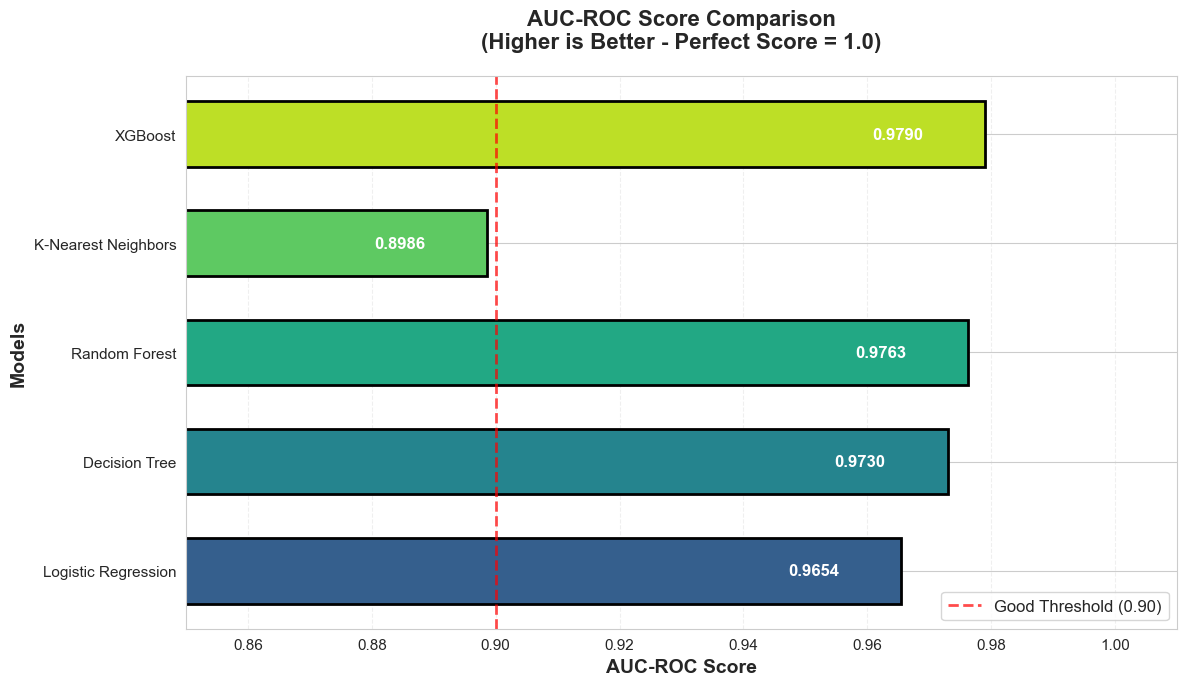


 Plot 3 saved as 'plot_3_auc_roc_comparison.png'
AUC-ROC SUMMARY STATISTICS

Best AUC-ROC: 0.9790 (XGBoost)
Worst AUC-ROC: 0.8986 (K-Nearest Neighbors)
Average AUC-ROC: 0.9585

Interpretation:
  • 0.90-1.00: Excellent discrimination
  • 0.80-0.90: Good discrimination
  • 0.70-0.80: Fair discrimination
  • < 0.70: Poor discrimination


In [33]:
# PLOT 3: AUC-ROC SCORE COMPARISON


fig, ax = plt.subplots(figsize=(12, 7))

# Creating color gradient
colors = plt.cm.viridis(np.linspace(0.3, 0.9, len(results_df)))

# Creating horizontal bar chart
bars = ax.barh(results_df['Model'], results_df['AUC-ROC'], color=colors, 
               edgecolor='black', linewidth=2, height=0.6)

# Customizing plot
ax.set_xlabel('AUC-ROC Score', fontsize=14, fontweight='bold')
ax.set_ylabel('Models', fontsize=14, fontweight='bold')
ax.set_title('AUC-ROC Score Comparison\n(Higher is Better - Perfect Score = 1.0)', 
             fontsize=16, fontweight='bold', pad=20)
ax.set_xlim(0.85, 1.01)
ax.grid(axis='x', alpha=0.3, linestyle='--')

# Adding value labels on bars
for i, (bar, value) in enumerate(zip(bars, results_df['AUC-ROC'])):
    ax.text(value - 0.01, bar.get_y() + bar.get_height()/2.,
            f'{value:.4f}',
            ha='right', va='center', fontsize=12, fontweight='bold', color='white')

# Adding reference line for "good" threshold (0.90)
ax.axvline(x=0.90, color='red', linestyle='--', linewidth=2, alpha=0.7, label='Good Threshold (0.90)')
ax.legend(fontsize=12, loc='lower right')

plt.tight_layout()
plt.savefig('plot_3_auc_roc_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n Plot 3 saved as 'plot_3_auc_roc_comparison.png'")

# Summary statistics
print("AUC-ROC SUMMARY STATISTICS")
print(f"\nBest AUC-ROC: {results_df['AUC-ROC'].max():.4f} ({results_df.loc[results_df['AUC-ROC'].idxmax(), 'Model']})")
print(f"Worst AUC-ROC: {results_df['AUC-ROC'].min():.4f} ({results_df.loc[results_df['AUC-ROC'].idxmin(), 'Model']})")
print(f"Average AUC-ROC: {results_df['AUC-ROC'].mean():.4f}")
print(f"\nInterpretation:")
print(f"  • 0.90-1.00: Excellent discrimination")
print(f"  • 0.80-0.90: Good discrimination")
print(f"  • 0.70-0.80: Fair discrimination")
print(f"  • < 0.70: Poor discrimination")


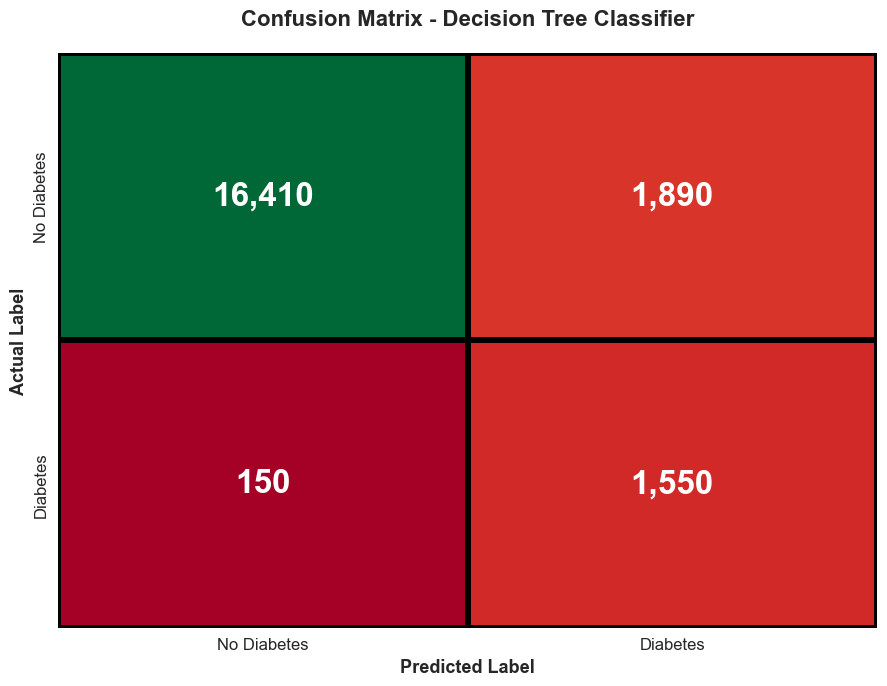

 Confusion matrix saved as 'confusion_matrix_decision_tree.png'


In [34]:
# CONFUSION MATRIX - DECISION TREE MODEL

from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Getting Decision Tree model and predictions
decision_tree_model = models['Decision Tree']
y_pred_dt = decision_tree_model.predict(X_test_scaled)

# Calculating confusion matrix
cm = confusion_matrix(y_test, y_pred_dt)
tn, fp, fn, tp = cm.ravel()

fig, ax = plt.subplots(figsize=(9, 7))

cm_display = np.array([[tn, fp], [fn, tp]])

sns.heatmap(cm_display, annot=False, cmap='RdYlGn', 
            xticklabels=['No Diabetes', 'Diabetes'],
            yticklabels=['No Diabetes', 'Diabetes'],
            cbar=False, ax=ax, linewidths=4, linecolor='black')

# Adding large count labels
ax.text(0.5, 0.5, f'{tn:,}', ha='center', va='center', 
        fontsize=24, fontweight='bold', color='white')
ax.text(1.5, 0.5, f'{fp:,}', ha='center', va='center', 
        fontsize=24, fontweight='bold', color='white')
ax.text(0.5, 1.5, f'{fn:,}', ha='center', va='center', 
        fontsize=24, fontweight='bold', color='white')
ax.text(1.5, 1.5, f'{tp:,}', ha='center', va='center', 
        fontsize=24, fontweight='bold', color='white')

ax.set_title('Confusion Matrix - Decision Tree Classifier', fontsize=16, fontweight='bold', pad=20)
ax.set_xlabel('Predicted Label', fontsize=13, fontweight='bold')
ax.set_ylabel('Actual Label', fontsize=13, fontweight='bold')
ax.tick_params(axis='both', labelsize=12)

plt.tight_layout()
plt.savefig('confusion_matrix_decision_tree.png', dpi=300, bbox_inches='tight')
plt.show()

print(f" Confusion matrix saved as 'confusion_matrix_decision_tree.png'")


In [35]:

# SAVING DECISION TREE MODEL FOR STREAMLIT DEPLOYMENT

import joblib
import os
import pandas as pd
import numpy as np

# Getting the Decision Tree model
decision_tree_model = models['Decision Tree']

# Creating models directory if it doesn't exist
os.makedirs('models', exist_ok=True)


# 1. SAVING THE MODEL


print("\n Saving Decision Tree Model...")
joblib.dump(decision_tree_model, 'models/diabetes_model.pkl')
print("   Model saved to 'models/diabetes_model.pkl'")


# 2. SAVING THE SCALER (for feature scaling)


print("\n Saving Scaler...")
joblib.dump(scaler, 'models/scaler.pkl')
print("   ✓ Scaler saved to 'models/scaler.pkl'")


# 3. SAVING FEATURE COLUMNS (for input validation)


print("\n Saving Feature Columns...")
feature_columns = X.columns.tolist()
joblib.dump(feature_columns, 'models/feature_columns.pkl')
print(f"   ✓ Feature columns saved to 'models/feature_columns.pkl'")
print(f"   Features: {feature_columns}")

# 4. SAVING FEATURE ENGINEERING INFO

print("\n Saving Feature Engineering Information...")

# Saving mappings for categorical variables
feature_engineering_info = {
    'gender_mapping': {'Female': 0, 'Male': 1, 'Other': 2},
    'smoking_mapping': {
        'never': 0,
        'former': 1,
        'current': 2,
        'ever': 3,
        'not current': 4,
        'No Info': 5
    },
    'numerical_features': numerical_features,
    'feature_columns': feature_columns,
    'model_type': 'Decision Tree Classifier',
    'model_accuracy': 0.8980,
    'model_recall': 0.9118,   
}

joblib.dump(feature_engineering_info, 'models/feature_engineering_info.pkl')
print("   ✓ Feature engineering info saved to 'models/feature_engineering_info.pkl'")


 Saving Decision Tree Model...
   Model saved to 'models/diabetes_model.pkl'

 Saving Scaler...
   ✓ Scaler saved to 'models/scaler.pkl'

 Saving Feature Columns...
   ✓ Feature columns saved to 'models/feature_columns.pkl'
   Features: ['gender', 'age', 'hypertension', 'heart_disease', 'smoking_history', 'bmi', 'HbA1c_level', 'blood_glucose_level', 'bmi_category', 'age_group', 'glucose_hba1c_ratio', 'age_bmi_interaction', 'risk_score']

 Saving Feature Engineering Information...
   ✓ Feature engineering info saved to 'models/feature_engineering_info.pkl'
